In [1]:
from dataclasses import dataclass
import stim
import math
from collections import defaultdict
@dataclass
class ColorCodeTile:
    qubits: list
    ancilla: tuple
    color: str
    shape: int #[4-square, 6-hex, etc]
    #currently use 8 for normal octagon, 80,81,82 for the 3 octagon variants
    
class ColorCodeCircuit488Test:
    
    def __init__(self, distance, rounds, noise=None):
        #super().__init__(distance, rounds)
        self.qubits = set()
        self.ancilla = set()
        self._tiles = self._generate_layout(distance)
        self.circuit = self._build_circuit(rounds, noise)
        self._ZL = []
        
        

    def get_circuit(self):
        return self.circuit
    
    def draw_layout(self):
        if self._tiles is None:
            return
        draw_tiles(self._tiles)

    def _generate_layout(self, distance:int):
        # Implementation for 4.8.8 layout generation
        if (distance-1)%4==0:
            layout = 1
        else:
            layout = 0
        tiles = []
        
        basenum = distance//2
        side = math.ceil(basenum/2)
        rightmost = 0
        zlset = set()
        #add the base green
        curr = [5,0]
        for _ in range(basenum):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(-3,0),(-1,2),(1,2),(3,0)]],
                tuple(curr),
                'green',
                80
            )
            tiles.append(tile)
            rightmost = curr[0]+3
            curr[0] += 8
        
        curr = [2,2]
        for ind in range(side):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(-2,-2),(0,-2),(2,0),(2,2)]],
                tuple(curr),
                'blue',
                81
            )
            tiles.append(tile)
            #left down
            coord = [curr[0]-1, curr[1]-3]
            issquare = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'blue',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -= 4

            #right down
            coord = [curr[0]+3, curr[1]+1]
            issquare = True
            firstred = True
            firstgreen = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                    if ind==side-1 and firstred:
                        zlset.add((coord[0]+1,coord[1]+1))
                        zlset.add((coord[0]+1, coord[1]-1))
                        firstred = False
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'green',
                        8
                    )
                    if ind==side-1 and firstgreen:
                        zlset.add((coord[0]+1,coord[1]+3))
                        zlset.add((coord[0]+3, coord[1]+1))
                        firstgreen = False
                tiles.append(tile)
                issquare = not issquare
                coord[1] -=4
            
            curr[0] += 8
            curr[1] += 8
        
        curr = [rightmost-4, 6]
        for _ in range(basenum-side):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(2,-2),(0,-2),(-2,0),(-2,2)]],
                tuple(curr),
                'green',
                82
            )
            tiles.append(tile)
            #right down
            coord = [curr[0]+1, curr[1]-3]
            issquare = True
            firstrightred = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                    if firstrightred:
                        zlset.add((coord[0]+1,coord[1]+1))
                        zlset.add((coord[0]+1, coord[1]-1))
                        firstrightred = False
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'green',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -= 4

            #left down
            coord = [curr[0]-3, curr[1]+1]
            issquare = True
            firstleftred = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                    if firstleftred:
                        zlset.add((coord[0]+1,coord[1]+1))
                        zlset.add((coord[0]-1, coord[1]+1))
                        firstleftred = False
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'blue',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -=4
            
            curr[0] -= 8
            curr[1] += 8

        zlset.add((rightmost,0))
        
        if layout==1:
            n = (rightmost+1)//2
            for i in range(len(tiles)):
                tiles[i].qubits = [((2*n)-x,y) for x,y in tiles[i].qubits]
                tiles[i].ancilla = (2*n - tiles[i].ancilla[0], tiles[i].ancilla[1])
                if tiles[i].color == 'green':
                    tiles[i].color = 'blue'
                elif tiles[i].color == 'blue':
                    tiles[i].color = 'green'
                if tiles[i].shape == 81:
                    tiles[i].shape = 82
                elif tiles[i].shape == 82:
                    tiles[i].shape = 81
            zlset = {((2*n)-x,y) for x,y in zlset}

        #current impl needs to be tested
        self._ZL = list(zlset)
        self._ZL.sort()
        if layout==0:
            for tile in tiles:
                assert len(zlset & set(tile.qubits)) % 2 == 0

        return tiles


    def _build_circuit(self, rounds, noise=None):
        """Implementation for building the 4.8.8 syndrome extraction circuit """
        circ = stim.Circuit()
        add_noise = noise is not None
        self._tiles.sort(key=lambda x:x.ancilla)
        
        for tile in self._tiles:
            self.qubits.update(q for q in tile.qubits)
            self.ancilla.add(tile.ancilla)
        sorted_q_a = sorted(self.qubits | self.ancilla)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        qubit_idxs = []
        
        #append qubit coordinates
        for q,i in qa_index_map.items():
            circ.append("QUBIT_COORDS", [i], q)
            qubit_idxs.append(i)

        #set qubits to 0
        circ.append("R", qubit_idxs)
        if add_noise:
            circ.append("X_ERROR", qubit_idxs, noise)
        #print(f'all qubits: {self.qubits}')
        #print(f'all ancilla: {self.ancilla}')
        circ.append("TICK")

        #0th/initialisation round
        circ += self._measure_stab(qa_index_map, False, noise)

        #steady state rounds
        circ += (rounds - 1) * self._measure_stab(qa_index_map, True, noise, noise)
        #circ += self._measure_stab(qa_index_map, True)

        #final observable readout
        circ += self._measure_obs(qa_index_map, noise)

        return circ

    def _stab_measure(self, qtoimap, basis, noise=None, measure_noise=None):
        stab_circ = stim.Circuit()
        add_noise = noise is not None
        add_m_noise = measure_noise is not None
        ancilla_idxs = [qtoimap[a.ancilla] for a in self._tiles]
        all_idxs = {qtoimap[q] for q in self.qubits}
        all_idxs.update(ancilla_idxs)
        
        oct_dirs = [(-1,3),(1,3),(-3,1),(3,1),(-3,-1),(3,-1),(-1,-3),(1,-3)]
        oct0_dirs = [(-1,2),(1,2),(-3,0),(3,0),None,None,None,None]
        oct1_dirs = [None,None,None,(2,2),None,(2,0),(-2,-2),(0,-2)]
        oct2_dirs = [None,None,(-2,2),None,(-2,0),None,(0,-2),(2,-2)]
        square_dirs = [(-1,1),(1,1),(-1,-1),(1,-1)]
        if basis == 'X':
            stab_circ.append("RX", ancilla_idxs)
            if add_noise:
                stab_circ.append("Z_ERROR", ancilla_idxs, noise)
        else:
            stab_circ.append("R", ancilla_idxs)
            if add_noise:
                stab_circ.append("X_ERROR", ancilla_idxs, noise)
        stab_circ.append("TICK")
        for step in range(8):
            measurements = []
            depolarise_ops = set()
            for tile in self._tiles:
                ax,ay = tile.ancilla
                aidx = qtoimap[tile.ancilla]
                if tile.shape != 4:
                    #octagon cases
                    #check for edge case of it being a halved octagon
                    if tile.shape == 8:
                        dirs = oct_dirs[step]
                    elif tile.shape == 80:
                        dirs = oct0_dirs[step]
                    elif tile.shape == 81:
                        dirs = oct1_dirs[step]
                    else:
                        dirs = oct2_dirs[step]
                    if dirs is None:
                        continue
                    dx,dy = dirs
                elif tile.shape == 4 and step>=4:
                    continue
                else:
                    dx,dy = square_dirs[step]
                qx, qy = ax+dx, ay+dy
                
                if (qx,qy) not in qtoimap.keys():
                    print(f" ancilla: {tile.ancilla}, dxdy = {dx,dy}, qubit: {qx,qy}")
                    print(f"missing key in obs: {qx,qy}, shape = {tile.shape}")
                    continue
                didx = qtoimap[(qx,qy)]
                if basis == 'Z':  
                    measurements.extend([didx, aidx])
                    depolarise_ops.update([didx, aidx])
                else:
                    measurements.extend([aidx, didx])
                    depolarise_ops.update([aidx, didx])
            if measurements:
                stab_circ.append("CNOT", measurements)
                if add_noise:
                    #cnot noise + idle noise
                    stab_circ.append("DEPOLARIZE2", depolarise_ops, noise)#temp replace w 2 dep 1s for 
                    #stab_circ.append("DEPOLARIZE1", depolarise_ops, noise)#horrible wont recommend
                    stab_circ.append("DEPOLARIZE1", [i for i in all_idxs if i not in depolarise_ops], noise)
                stab_circ.append("TICK")
        #measurement
        if add_m_noise:
            if basis == "Z":   
                stab_circ.append("M", ancilla_idxs, measure_noise)
                
            else:
                stab_circ.append("MX", ancilla_idxs, measure_noise)
        else:
            if basis == "Z":   
                stab_circ.append("M", ancilla_idxs)
                
            else:
                stab_circ.append("MX", ancilla_idxs)
        stab_circ.append("TICK")
        return stab_circ

    def _measure_obs(self, qtoimap, noise):
        obs_circ = stim.Circuit()
        
        # measure qubits
        sorted_qs = sorted(list(self.qubits))
        q_idxs = [qtoimap[q] for q in sorted_qs]
        obs_circ.append("M", q_idxs, noise)

        # final z-detectors
        q_rec_offsets = {q_idx : -len(q_idxs) + k for k,q_idx in enumerate(q_idxs)}
        a_index = {a:i for i,a in enumerate(self.ancilla)}
        #print(f'aidxs = {a_index}')
        #print(f'tiles anc {self._tiles}')
        for i, tile in enumerate(self._tiles):
            targets = [stim.target_rec(q_rec_offsets[qtoimap[q]]) for q in tile.qubits]
            print(f"measuring {[qtoimap[q] for q in tile.qubits]}")
            a_offset = -len(q_idxs) - (len(self._tiles) - i)
            targets.append(stim.target_rec(a_offset))
            chrom_color = {'red':0,'green':1,'blue':2}[tile.color]
            chrom_annotation = chrom_color + 3
            obs_circ.append("DETECTOR", targets, [tile.ancilla[0], tile.ancilla[1], 0, chrom_annotation])
    

        # logical observable
        #logical_z_qubits = [q for q in sorted_qs if q[1]==0]
        """
        lzcoords = set()
        supp = defaultdict(int)
        
        for tile in self._tiles:
            for q in tile.qubits:
                supp[q]+=1
            if tile.color == 'green' and tile.shape >= 80:
                lzcoords |= set(tile.qubits)
                
        lzidxs = [qtoimap[q] for q in lzcoords]
        print(f" observable ids { lzidxs}")
        #print(supp)
        obs_targets = [stim.target_rec(q_rec_offsets[qtoimap[q]]) for q in lzcoords]
        obs_circ.append("OBSERVABLE_INCLUDE", obs_targets, 0)"""

        targetqs = []
        for q in self.qubits:
            if q[1]==0:
                targetqs.append(q)

        targets = [7,8,9]
        obs_targets = [stim.target_rec(q_rec_offsets[q]) for q in targets]
        obs_circ.append("OBSERVABLE_INCLUDE", obs_targets, 0)
        print(targets)
        
        return obs_circ


    def _measure_stab(self, qtoimap, include_detectors, data_noise=None, measure_noise=None):
        stab_circ = stim.Circuit()
        add_noise = data_noise is not None
        add_m_noise = measure_noise is not None
        oct_dirs = [(-1,3),(1,3),(-3,1),(3,1),(-3,-1),(3,-1),(1,-3),(-1,-3)]
        square_dirs = [(-1,1),(1,1),(-1,-1),(1,-1)]
        

        for basis in ['X', 'Z']:
            #reset ancillas
            stab_circ += self._stab_measure(qtoimap, basis, data_noise, measure_noise)
        
        if include_detectors:
            num_stabilizers = len(self._tiles) * 2
            for xz in range(2):
                for k, tile in enumerate(self._tiles):
                    ax, ay = tile.ancilla
                    chrom_color = {'red':0,'green':1,'blue':2}[tile.color]
                    chrom_annotation = chrom_color + 3*xz
                    offset = xz*len(self._tiles) + k
                    
                    stab_circ.append("DETECTOR", [stim.target_rec(-(num_stabilizers - offset)),
                                          stim.target_rec(-num_stabilizers*2+offset)],
                                          [ax, ay, 0, chrom_annotation])
                    
        if add_noise:
            stab_circ.append("DEPOLARIZE1", [qtoimap[q] for q in self.qubits], data_noise)

        if include_detectors:
            stab_circ.append("SHIFT_COORDS", [], [0,0,1])
        stab_circ.append("TICK")

        return stab_circ

In [48]:
ccCircTest = ColorCodeCircuit488Test(3,2,1e-3)
c1 = ccCircTest.get_circuit()
print(c1)
#c1.diagram("detslice-svg")
#print(c1.num_observables)
#dem = c1.detector_error_model()
#dem.diagram("matchgraph-3d")

measuring [0, 1, 3, 4]
measuring [1, 3, 7, 9]
measuring [3, 4, 8, 7]
[0, 1, 9]
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(2, 0) 1
QUBIT_COORDS(2, 2) 2
QUBIT_COORDS(4, 2) 3
QUBIT_COORDS(4, 4) 4
QUBIT_COORDS(5, 0) 5
QUBIT_COORDS(5, 3) 6
QUBIT_COORDS(6, 2) 7
QUBIT_COORDS(6, 4) 8
QUBIT_COORDS(8, 0) 9
R 0 1 2 3 4 5 6 7 8 9
X_ERROR(0.001) 0 1 2 3 4 5 6 7 8 9
TICK
RX 2 5 6
Z_ERROR(0.001) 2 5 6
TICK
CX 5 3 6 4
DEPOLARIZE2(0.001) 3 4 5 6
DEPOLARIZE1(0.001) 0 1 2 7 8 9
TICK
CX 5 7 6 8
DEPOLARIZE2(0.001) 8 5 6 7
DEPOLARIZE1(0.001) 0 1 2 3 4 9
TICK
CX 5 1 6 3
DEPOLARIZE2(0.001) 1 3 5 6
DEPOLARIZE1(0.001) 0 2 4 7 8 9
TICK
CX 2 4 5 9 6 7
DEPOLARIZE2(0.001) 2 4 5 6 7 9
DEPOLARIZE1(0.001) 0 1 3 8
TICK
CX 2 3
DEPOLARIZE2(0.001) 2 3
DEPOLARIZE1(0.001) 0 1 4 5 6 7 8 9
TICK
CX 2 0
DEPOLARIZE2(0.001) 0 2
DEPOLARIZE1(0.001) 1 3 4 5 6 7 8 9
TICK
CX 2 1
DEPOLARIZE2(0.001) 1 2
DEPOLARIZE1(0.001) 0 3 4 5 6 7 8 9
TICK
MX 2 5 6
TICK
R 2 5 6
X_ERROR(0.001) 2 5 6
TICK
CX 3 5 4 6
DEPOLARIZE2(0.001) 3 4 5 6
DEPOLARIZE1(0.001)

measuring [0, 1, 3, 4]
measuring [1, 3, 7, 9]
measuring [3, 4, 8, 7]
[7, 8, 9]
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(2, 0) 1
QUBIT_COORDS(2, 2) 2
QUBIT_COORDS(4, 2) 3
QUBIT_COORDS(4, 4) 4
QUBIT_COORDS(5, 0) 5
QUBIT_COORDS(5, 3) 6
QUBIT_COORDS(6, 2) 7
QUBIT_COORDS(6, 4) 8
QUBIT_COORDS(8, 0) 9
R 0 1 2 3 4 5 6 7 8 9
TICK
RX 2 5 6
TICK
CX 5 3 6 4
TICK
CX 5 7 6 8
TICK
CX 5 1 6 3
TICK
CX 2 4 5 9 6 7
TICK
CX 2 3
TICK
CX 2 0
TICK
CX 2 1
TICK
MX 2 5 6
TICK
R 2 5 6
TICK
CX 3 5 4 6
TICK
CX 7 5 8 6
TICK
CX 1 5 3 6
TICK
CX 4 2 9 5 7 6
TICK
CX 3 2
TICK
CX 0 2
TICK
CX 1 2
TICK
M 2 5 6
TICK
TICK
REPEAT 4 {
    RX 2 5 6
    TICK
    CX 5 3 6 4
    TICK
    CX 5 7 6 8
    TICK
    CX 5 1 6 3
    TICK
    CX 2 4 5 9 6 7
    TICK
    CX 2 3
    TICK
    CX 2 0
    TICK
    CX 2 1
    TICK
    MX 2 5 6
    TICK
    R 2 5 6
    TICK
    CX 3 5 4 6
    TICK
    CX 7 5 8 6
    TICK
    CX 1 5 3 6
    TICK
    CX 4 2 9 5 7 6
    TICK
    CX 3 2
    TICK
    CX 0 2
    TICK
    CX 1 2
    TICK
    M 2 5 6
    TICK


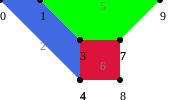

In [2]:
import svgwrite
from IPython.display import SVG, display
color_map = {
    'red':'crimson',
    'green':'lime',
    'blue':'royalblue'
    }

CC = ColorCodeCircuit488Test(3,5)
layout = CC._generate_layout(3)
print(CC.get_circuit())
def draw_tiles(tiles):
    width = max(x for tile in tiles for x,y in tile.qubits)
    height = max(y for tile in tiles for x,y in tile.qubits)
    drawing = svgwrite.Drawing(size = (width*20+20, height*20+20))
    sorted_q_a = sorted(CC.qubits | CC.ancilla)
    qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
    for tile in tiles:
        drawing.add(drawing.polygon(
            points = [(x*20, y*20) for x,y in tile.qubits],
            fill = color_map[tile.color]
        ))
        #drawing.add(drawing.circle(center=(tile.ancilla[0]*20, tile.ancilla[1]*20), r=3, fill='grey'))
        drawing.add(drawing.text(str(qa_index_map[tile.ancilla]),insert=(tile.ancilla[0]*20, tile.ancilla[1]*20+10), fill='grey'))
        for x,y in tile.qubits:
            drawing.add(drawing.circle(center=(x*20, y*20), r=3, fill='black'))
            drawing.add(drawing.text(str(qa_index_map[(x,y)]),insert=(x*20, y*20+20), fill='black'))
    
    svg_data = drawing.tostring()
    display(SVG(svg_data))

draw_tiles(layout)

In [3]:
cc = ColorCodeCircuit488Test(11,3)
c2 = cc.get_circuit()
#url = c2.to_crumble_url()
#print(f'url: {url}')
dem = c2.detector_error_model()

sampler = stim.CompiledDetectorSampler(c2)
# sample once with seed to see detectors:
detector_sample = sampler.sample(shots=5)
print(detector_sample)  # should be all zeros


explanation = c2.explain_detector_error_model_errors(
    dem_filter=dem, 
    reduce_to_one_representative_error=True
)
#print(explanation)
#print(c2)

measuring [0, 1, 3, 4]
measuring [1, 3, 7, 9]
measuring [3, 4, 8, 7]
measuring [8, 10, 15, 19, 18, 14, 9, 7]
measuring [10, 11, 16, 15]
measuring [11, 16, 20, 21]
measuring [14, 18, 26, 30]
measuring [18, 19, 27, 26]
measuring [16, 20, 28, 32, 31, 27, 19, 15]
measuring [20, 21, 29, 28]
measuring [27, 31, 40, 46, 45, 39, 30, 26]
measuring [31, 32, 41, 40]
measuring [29, 33, 42, 48, 47, 41, 32, 28]
measuring [33, 34, 43, 42]
measuring [34, 43, 49, 50]
measuring [39, 45, 57, 63]
measuring [45, 46, 58, 57]
measuring [41, 47, 59, 65, 64, 58, 46, 40]
measuring [47, 48, 60, 59]
measuring [43, 49, 61, 67, 66, 60, 48, 42]
measuring [49, 50, 62, 61]
measuring [58, 64, 73, 78, 77, 72, 63, 57]
measuring [64, 65, 74, 73]
measuring [60, 66, 75, 80, 79, 74, 65, 59]
measuring [66, 67, 76, 75]
measuring [89, 80, 75, 76]
measuring [72, 77, 86, 90]
measuring [77, 78, 87, 86]
measuring [74, 79, 88, 92, 91, 87, 78, 73]
measuring [79, 80, 89, 88]
measuring [87, 91, 96, 99, 98, 95, 90, 86]
measuring [91, 92,

ValueError: The circuit contains non-deterministic observables.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(38, 48), filter_coords=['L0', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 38:48 --filter_coords L0 > output_image.svg

This was discovered while analyzing an X-basis reset (RX) on:
    qubit 12 [coords (9, 3)]

The collapse anti-commuted with these detectors/observables:
    L0

The backward-propagating error sensitivity for L0 was:
    Z7 [coords (6, 2)]
    Z8 [coords (6, 4)]
    Z9 [coords (8, 0)]
    Z12 [coords (9, 3)]

Circuit stack trace:
    during TICK layer #44 of 65
    at instruction #150 [which is a REPEAT 2 block]
    at block's instruction #1 [which is RX 2 5 6 12 13 17 22 23 24 25 35 36 37 38 44 51 52 53 54 55 56 68 69 70 71 81 82 83 84 85 93 94 100 101 102]

In [5]:
import os
import sys

print(os.getcwd())
# 1. Navigate UP two levels to the project root:
#    preparation/ -> CST-Part-II-Project-Code/
os.chdir('./color_code_experiments')

c:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code


In [6]:
import stim
with open("singleerrorcirc.txt") as f:
    r = f.read()

circ = stim.Circuit(r)
dem = circ.detector_error_model()

explanation = circ.explain_detector_error_model_errors(
    dem_filter=dem, 
    reduce_to_one_representative_error=True
)
print(explanation)
circ.diagram("detslice-with-ops-svg")

[stim.ExplainedError(dem_error_terms=(stim.DemTargetWithCoords(dem_target=stim.DemTarget('D121'), coords=[5, 0, 4, 4]),stim.DemTargetWithCoords(dem_target=stim.DemTarget('D122'), coords=[5, 3, 4, 3]),stim.DemTargetWithCoords(dem_target=stim.DemTarget('D123'), coords=[9, 3, 4, 5]),), circuit_error_locations=(stim.CircuitErrorLocation(tick_offset=106, flipped_pauli_product=(stim.GateTargetWithCoords(stim.target_x(7), [6, 2]),), flipped_measurement=stim.FlippedMeasurement(
    record_index=None,
    observable=(),
), instruction_targets=stim.CircuitTargetsInsideInstruction(gate='DEPOLARIZE1', args=[0.001], target_range_start=0, target_range_end=1, targets_in_range=(stim.GateTargetWithCoords(7, [6, 2]),)), stack_frames=(stim.CircuitErrorLocationStackFrame(
    instruction_offset=90,
    iteration_index=0,
    instruction_repetitions_arg=0,
),)),))]


QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(0, 1) 1
QUBIT_COORDS(0, 2) 2
QUBIT_COORDS(1, 0) 3
QUBIT_COORDS(1, 1) 4
QUBIT_COORDS(1, 2) 5
QUBIT_COORDS(2, 0) 6
QUBIT_COORDS(2, 1) 7
QUBIT_COORDS(2, 2) 8
QUBIT_COORDS(2, 3) 9
QUBIT_COORDS(2, 4) 10
QUBIT_COORDS(3, 0) 11
QUBIT_COORDS(3, 1) 12
QUBIT_COORDS(3, 2) 13
QUBIT_COORDS(3, 3) 14
QUBIT_COORDS(3, 4) 15
QUBIT_COORDS(4, 0) 16
QUBIT_COORDS(4, 1) 17
QUBIT_COORDS(4, 2) 18
QUBIT_COORDS(4, 3) 19
QUBIT_COORDS(4, 4) 20
RX 2 6 8 16 18 20
R 0 3 4 5 10 11 12 13 14 15 17 1 7 9 19
X_ERROR(0.001) 0 3 4 5 10 11 12 13 14 15 17 1 7 9 19
Z_ERROR(0.001) 2 6 8 16 18 20
TICK
CX 4 1 6 3 8 5 12 7 14 9 16 11 18 13 20 15
DEPOLARIZE2(0.001) 4 1 6 3 8 5 12 7 14 9 16 11 18 13 20 15
DEPOLARIZE1(0.001) 0 2 10 17 19
TICK
CX 2 1 5 4 8 7 10 9 13 12 15 14 18 17 20 19
DEPOLARIZE2(0.001) 2 1 5 4 8 7 10 9 13 12 15 14 18 17 20 19
DEPOLARIZE1(0.001) 0 3 6 11 16
TICK
CX 0 1 3 4 6 7 9 8 11 12 14 13 16 17 19 18
DEPOLARIZE2(0.001) 0 1 3 4 6 7 9 8 11 12 14 13 16 17 19 18
DEPOLARIZE1(0.001) 2 

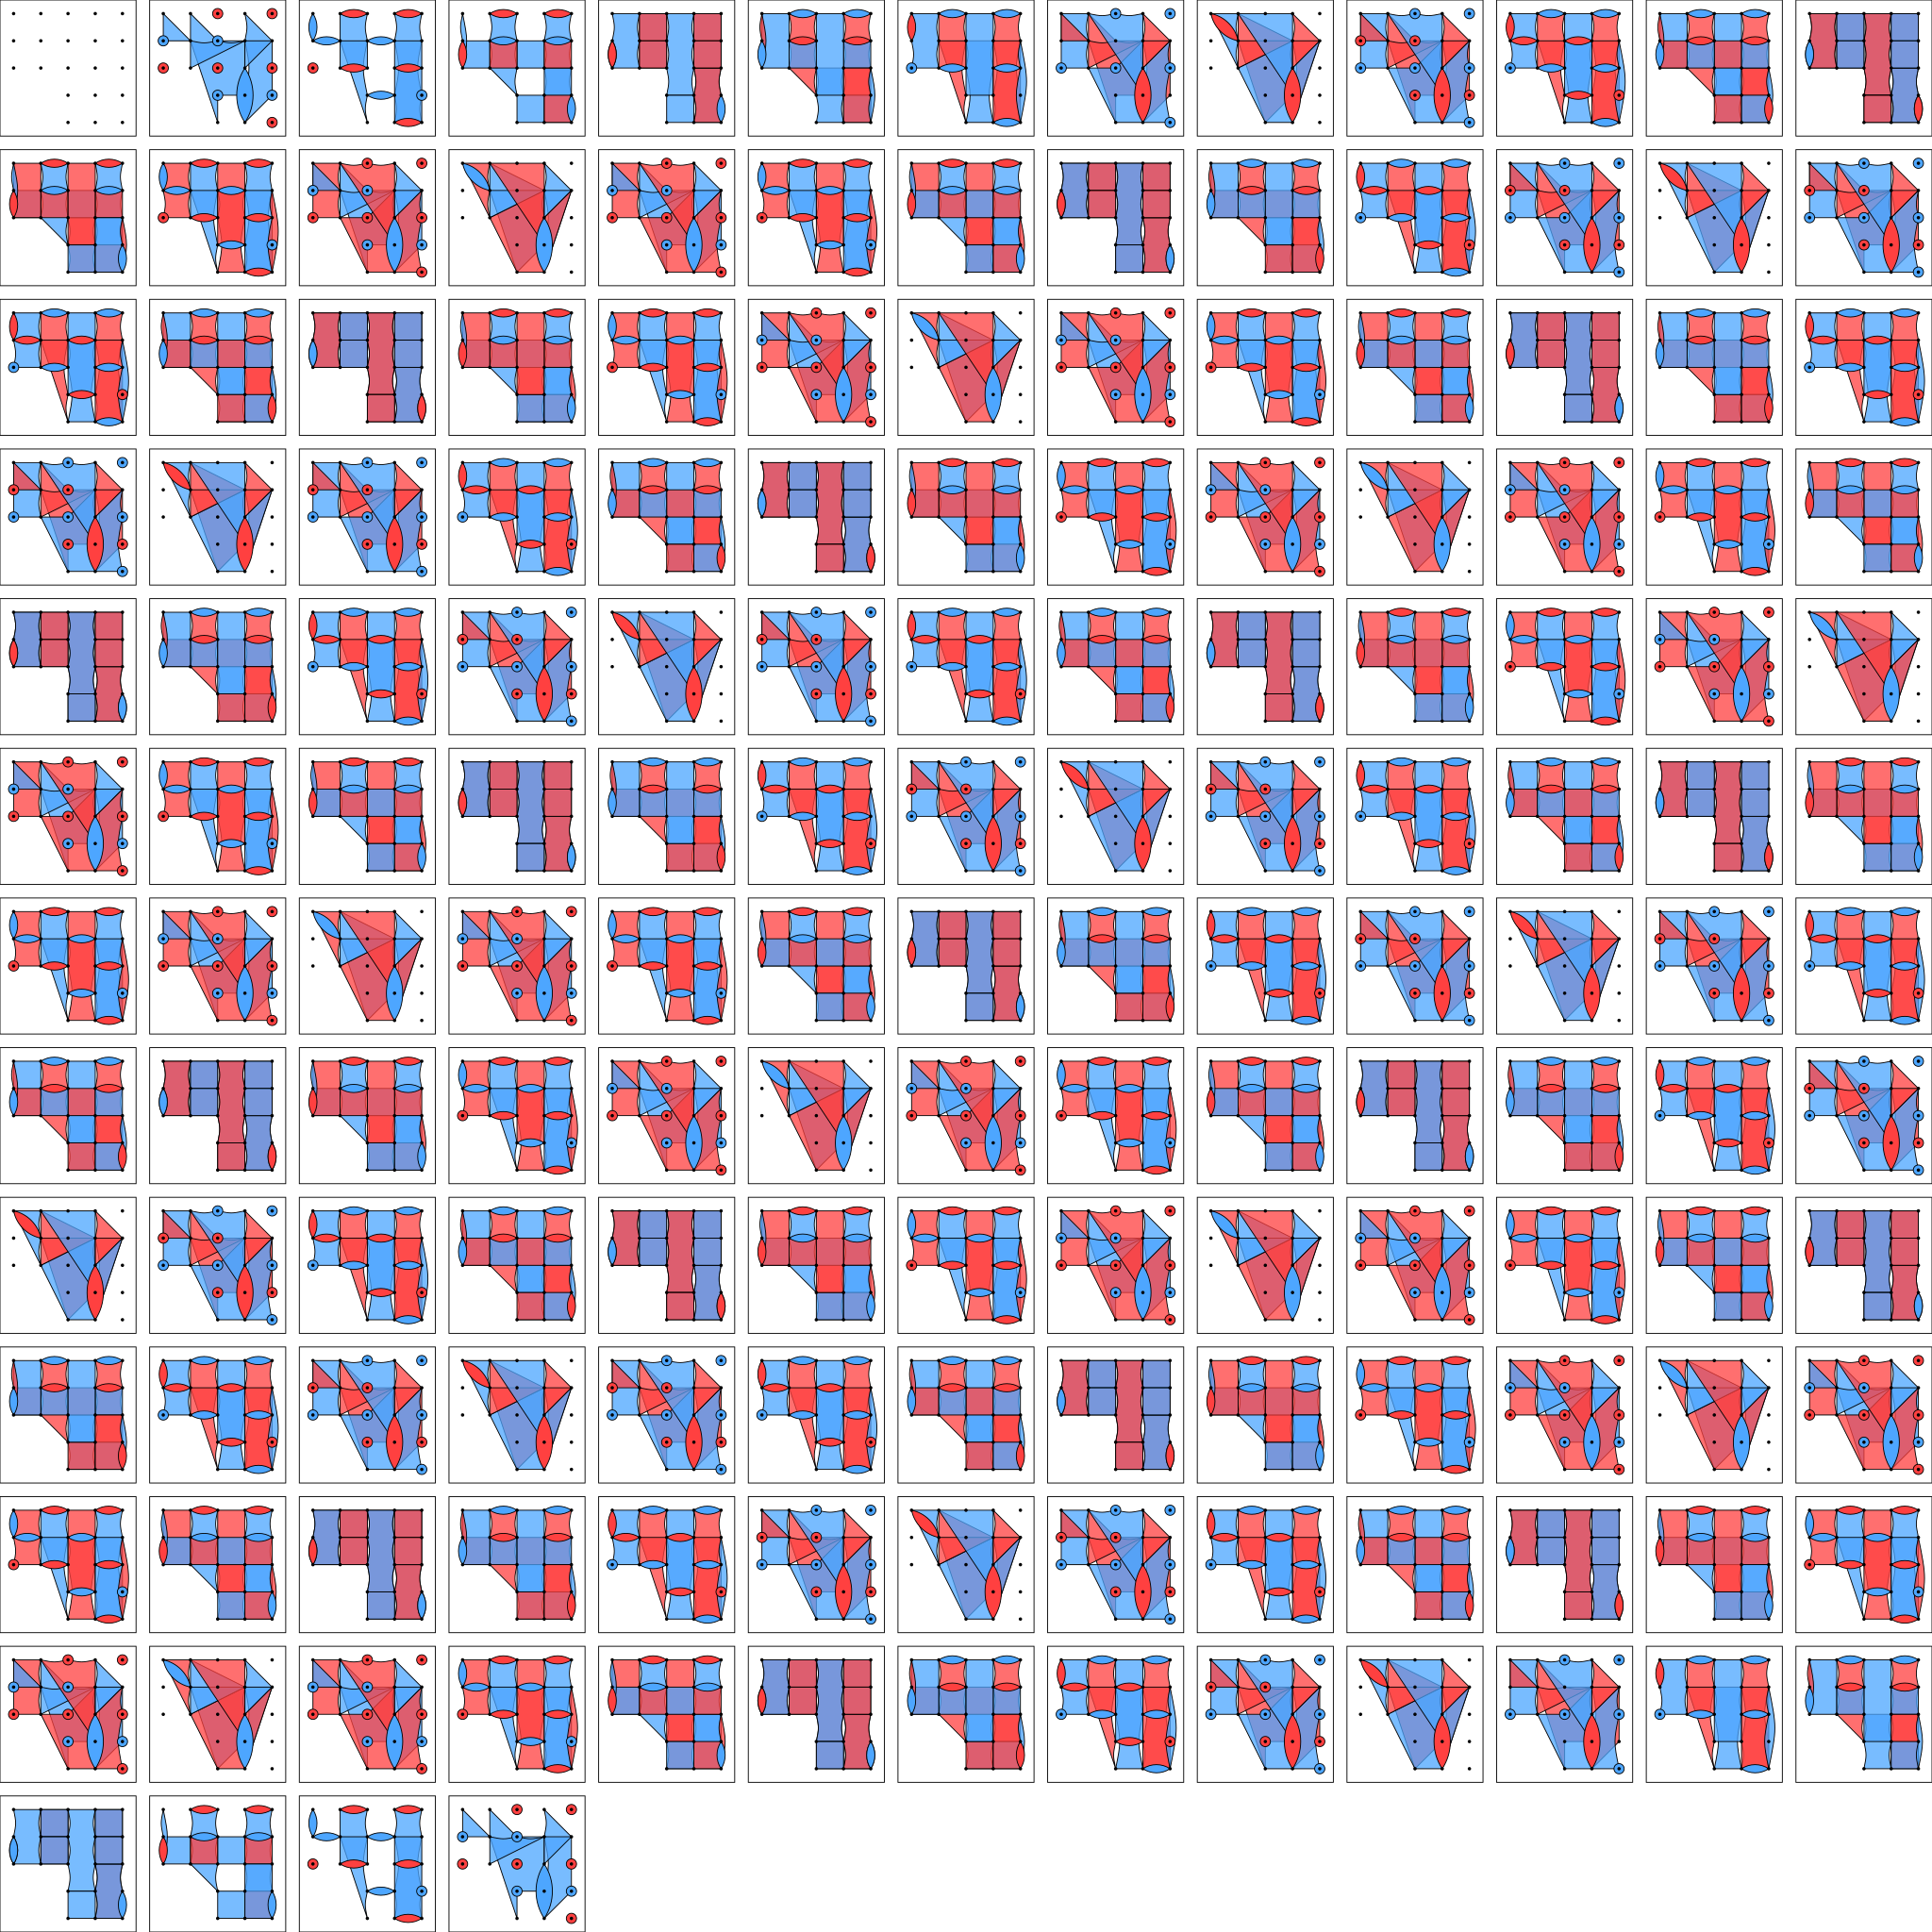

In [3]:
import stim
with open("r=20,d=5,p=0.001,noise=uniform,c=midout_color_code_488_Z,q=21,gates=all.stim") as f:
    c = f.read()

with open("r=28,d=7,p=0.001,noise=uniform,c=midout_color_code_488_Z,q=37,gates=all.stim") as f:
    c2 = f.read()
with open("r=44,d=11,p=0.001,noise=uniform,c=midout_color_code_488_X,q=81,gates=all.stim") as f:
    c3 = f.read()
    
circ = stim.Circuit(c)
circ2 = stim.Circuit(c2)
circ3=stim.Circuit(c3)
print(circ)
circ.diagram("detslice-svg")

Starting 12 workers...
3 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata    
        4 chromobius [draining]     998703         -24 d=5,p=0.001,r=20 
        4 chromobius          ?    1000000         100 d=7,p=0.001,r=28 
        4 chromobius          ?    1000000         100 d=11,p=0.001,r=44
2 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata    
        6 chromobius [draining]     994812        -294 d=7,p=0.001,r=28 
        6 chromobius          ?    1000000         100 d=11,p=0.001,r=44
1 tasks left:
  workers    decoder eta shots_left errors_left json_metadata    
       12 chromobius <1m     998908          72 d=11,p=0.001,r=44
1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata    
       12 chromobius [draining]     994949         -28 d=11,p=0.001,r=44
1 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata    
       12 chromobius [draining]     986484   

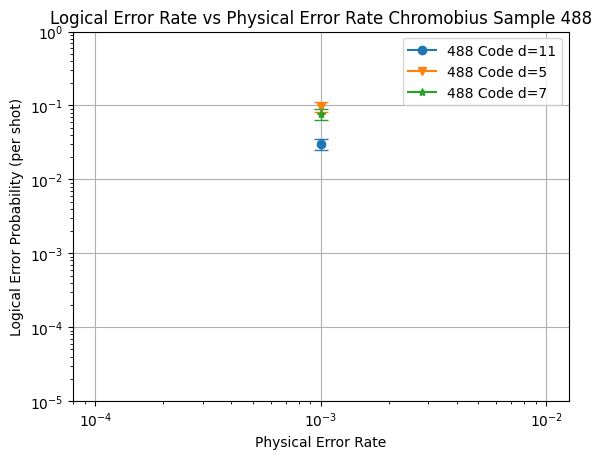

In [6]:
import sinter, chromobius
import matplotlib.pyplot as plt


tasks = [
    sinter.Task(
        circuit=circ,
        json_metadata={'d': 5, 'p': 0.001, 'r': 20},
    ),
    sinter.Task(
        circuit=circ2,
        json_metadata={'d': 7, 'p': 0.001, 'r': 28},
    ),
    sinter.Task(
        circuit=circ3,
        json_metadata={'d': 11, 'p': 0.001, 'r': 44},
    )
]

stats = sinter.collect(
    tasks=tasks,
    num_workers=os.cpu_count(),
    max_shots=1_000_000,
    max_errors=100,
    print_progress=True,
    decoders=['chromobius'],
    custom_decoders=chromobius.sinter_decoders(),
)
# Render a matplotlib plot of the data.
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    group_func=lambda stat: f"488 Code d={stat.json_metadata['d']}",
    x_func=lambda stat: stat.json_metadata['p'],
)
ax.loglog()
ax.set_ylim(1e-5, 1)
ax.grid()
ax.set_title('Logical Error Rate vs Physical Error Rate Chromobius Sample 488')
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_xlabel('Physical Error Rate')
ax.legend()

# Save to file and also open in a window.
fig.savefig('plot.png')
plt.show()

In [14]:
from src.color_code_utils.color_code_circuits.color_code_circuit_488 import ColorCodeCircuit488
import stim, sinter, chromobius

Starting 12 workers...


measuring [0, 1, 3, 4]
measuring [1, 3, 7, 9]
measuring [3, 4, 8, 7]
[7, 8, 9]
measuring [0, 1, 3, 4]
measuring [1, 3, 7, 9]
measuring [3, 4, 8, 7]
[7, 8, 9]
measuring [0, 1, 3, 4]
measuring [1, 3, 7, 9]
measuring [3, 4, 8, 7]
[7, 8, 9]


3 tasks left:
  workers    decoder eta shots_left errors_left json_metadata        
        4 chromobius <1m      75000        1000 d=3,p=0,r=12,b=Z     
        4 chromobius   ?     100000        1000 d=3,p=0.0001,r=12,b=Z
        4 chromobius   ?     100000        1000 d=3,p=1e-05,r=12,b=Z 
0 tasks left:



stats = [sinter.TaskStats(strong_id='009ed41ab191bc1c361eb491f3d2aff3bac3fed4c9e4e0d7deb087f007efa117', decoder='chromobius', json_metadata={'d': 3, 'p': 0, 'r': 12, 'b': 'Z'}, shots=100000, seconds=0.028212799992616056), sinter.TaskStats(strong_id='e2965bd5c2b2b89f56d22b8189891b3dd953ee9dc47c7bdb35dd66d6c224ea3b', decoder='chromobius', json_metadata={'d': 3, 'p': 1e-05, 'r': 12, 'b': 'Z'}, shots=100000, errors=np.int64(161), seconds=0.03429780000078608), sinter.TaskStats(strong_id='fcbbe6c1a5df4b59d1e620455c894b16dc4e701e12f6b1bc92ccbfb5cedf46bb', decoder='chromobius', json_metadata={'d': 3, 'p': 0.0001, 'r': 12, 'b': 'Z'}, shots=74971, errors=np.int64(1377), seconds=0.052038400011952035)]


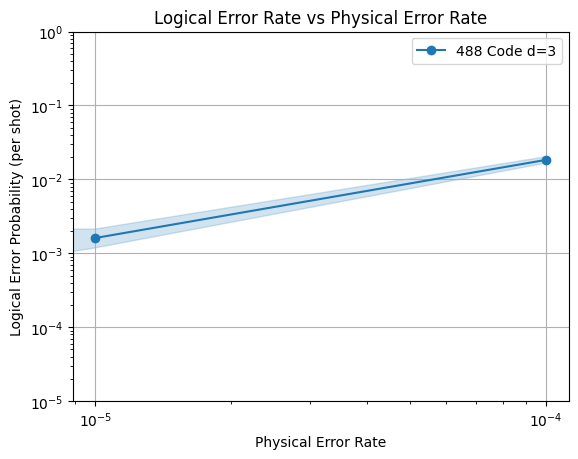

In [15]:
from src.color_code_utils.color_code_circuits.color_code_circuit_488 import ColorCodeCircuit488
import matplotlib.pyplot as plt


tasks = [
    sinter.Task(
        circuit=ColorCodeCircuit488Test(d,r,p).get_circuit(),
        json_metadata={'d': d, 'p': p, 'r': r, 'b': b},
    )
    for d in [3]
    for r in [d*4]
    for b in ['Z']
    for p in [0,0.0001,0.00001]
]

stats = sinter.collect(
    tasks=tasks,
    num_workers=os.cpu_count(),
    max_shots=100_000,
    max_errors=1000,
    print_progress=True,
    decoders=['chromobius'],
    custom_decoders=chromobius.sinter_decoders(),
)
print(f'stats = {stats}')
# Render a matplotlib plot of the data.
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    group_func=lambda stat: f"488 Code d={stat.json_metadata['d']}",
    x_func=lambda stat: stat.json_metadata['p'],
)
ax.loglog()
ax.set_ylim(1e-5, 1)
ax.grid()
ax.set_title('Logical Error Rate vs Physical Error Rate')
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_xlabel('Physical Error Rate')
ax.legend()

# Save to file and also open in a window.
fig.savefig('plot.png')
plt.show()